In [1]:
#Olist巴西电商综合运营分析
#平台整体销售走势、淡旺季在哪？
#哪些商品品类最热销，值得重点备货？
#哪些城市用户购买力强，适合投放市场、布局物流？
#用户偏好什么支付方式？平台要不要新增支付渠道？
#用户评价评分分布，整体满意度如何？低分原因在哪？
#商家地域分布、头部商家集中在哪？

# 数据来源：https://www.kaggle.com/olistbr/brazilian-ecommerce
# 请将 Kaggle 下载的 CSV 文件放入 ../data/ 目录下后再运行

import pandas as pd    
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')# 忽略无关冗余警告
plt.rcParams['font.sans-serif'] = ['SimHei']# 设置全局字体为黑体，解决matplotlib图表中文乱码问题
plt.rcParams['axes.unicode_minus'] = False# 解决图表坐标轴负号显示异常

#读取数据表
df_cus = pd.read_csv(r"..\data\olist_customers_dataset.csv")
df_ord = pd.read_csv(r"..\data\olist_orders_dataset.csv")
df_items = pd.read_csv(r"..\data\olist_order_items_dataset.csv")
df_prod = pd.read_csv(r"..\data\olist_products_dataset.csv")
df_sell = pd.read_csv(r"..\data\olist_sellers_dataset.csv")
df_rev = pd.read_csv(r"..\data\olist_order_reviews_dataset.csv")
df_pay = pd.read_csv(r"..\data\olist_order_payments_dataset.csv")
df_geo = pd.read_csv(r"..\data\olist_geolocation_dataset.csv")
df_cat_trans = pd.read_csv(r"..\data\product_category_name_translation.csv")
df_ord.columns = df_ord.columns.str.replace('"', '').str.strip()

In [2]:
# 查看订单表基础信息
print("===== 订单表基础信息 =====")
print(df_ord.dtypes)       # 查看字段类型
print(df_ord.describe())   # 数值字段统计分布
print(df_ord.isnull().sum() / len(df_ord))  # 缺失值占比

===== 订单表基础信息 =====
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered      2018-04-11 10:48:14  20

In [3]:
#逐级关联合并(左关联)
#订单 → 用户（谁买）customer_id
#订单 → 明细（买了什么）order_id
#明细 → 商品（什么品类）product_id
#明细 → 商家（谁卖）seller_id
#订单 → 评价（满意度）order_id
#订单 → 支付（怎么付钱）order_id
#商品 → 品类翻译（看懂品类）product_category_name

df_all = df_ord.merge(df_cus, on="customer_id", how="left")
df_all = df_all.merge(df_items, on="order_id", how="left")
df_all = df_all.merge(df_prod, on="product_id", how="left")
df_all = df_all.merge(df_sell, on="seller_id", how="left")
df_all = df_all.merge(df_rev, on="order_id", how="left")
df_all = df_all.merge(df_pay, on="order_id", how="left")
df_all = df_all.merge(df_cat_trans, on="product_category_name", how="left")

In [4]:
#查看关联后表中数据
df_all.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,credit_card,1.0,18.12,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3.0,voucher,1.0,2.00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.0,voucher,1.0,18.59,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1.0,boleto,1.0,141.46,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.0,credit_card,3.0,179.12,auto


In [5]:
# 查看表所有字段名称
df_all.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product_category_name_english'],
      dtype='object')

In [6]:
# 核心时间字段转标准时间格式
time_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date"
]
for col in time_cols:
    df_all[col] = pd.to_datetime(df_all[col], errors="coerce")

# 衍生年月、年份
df_all["year_month"] = df_all["order_purchase_timestamp"].dt.to_period("M")
df_all["year"] = df_all["order_purchase_timestamp"].dt.year

# 计算物流配送时长（天）
df_all["delivery_days"] = (df_all["order_delivered_customer_date"] 
                            - df_all["order_purchase_timestamp"]).dt.days

In [7]:
# 1.过滤价格<=0的异常测试订单
df_all = df_all[df_all["price"] > 0]

# 2.过滤物流时长为负数/极端异常值
df_all = df_all[(df_all["delivery_days"] >= 0) & (df_all["delivery_days"] <= 60)]

# 3.只保留已完成有效订单，剔除取消、退款、异常订单
df_all = df_all[df_all["order_status"] == "delivered"]

# 4.删除完全空行
df_all = df_all.dropna(how="all")

In [8]:
# 以用户ID聚合，构造用户维度特征
user_df = df_all.groupby("customer_id").agg(
    # RFM核心特征 
    total_spend = ("payment_value", "sum"),      # 总消费金额 M
    order_count = ("order_id", "nunique"),       # 下单频次 F
    last_order_time = ("order_purchase_timestamp", "max"), # 最近购买时间 R
    avg_delivery_days = ("delivery_days", "mean"),  # 平均物流时长
    avg_review_score = ("review_score", "mean")     # 平均评价分数
).reset_index()

# 查看用户特征表
user_df.head()

df_all.to_csv(r"..\data\order_master.csv", index=False, encoding="utf-8-sig")

In [9]:
# 把订单时间转成标准时间格式
user_df['last_order_time'] = pd.to_datetime(user_df['last_order_time'])

# 设定一个“观测截止日期”（用数据里最晚的时间）
current_date = user_df['last_order_time'].max()

# 计算 R：距离最后一次购买的天数
user_df['recency'] = (current_date - user_df['last_order_time']).dt.days 

In [10]:
# F = 订单次数（Frequency）
user_df['frequency'] = user_df['order_count']

# M = 总消费金额（Monetary）
user_df['monetary'] = user_df['total_spend']

In [11]:
# R 分箱（越小分越高）
user_df['R_score'] = pd.qcut(user_df['recency'], 5, labels=[5,4,3,2,1])

# F 分箱
user_df['F_score'] = pd.qcut(user_df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# M 分箱
user_df['M_score'] = pd.qcut(user_df['monetary'], 5, labels=[1,2,3,4,5])

In [12]:
# 转成整数
user_df['R_score'] = user_df['R_score'].astype(int)
user_df['F_score'] = user_df['F_score'].astype(int)
user_df['M_score'] = user_df['M_score'].astype(int)

# 计算 RFM 总分
user_df['RFM_total'] = user_df['R_score'] + user_df['F_score'] + user_df['M_score']

# 给用户分层
def rfm_segment(row):
    R = row['R_score']
    F = row['F_score']
    M = row['M_score']
    
    if R >=4 and F >=4 and M >=4:
        return '高价值用户'
    elif R >=4 and F <=2 and M >=3:
        return '潜力用户'
    elif R <=2 and F >=3 and M >=3:
        return '流失风险用户'
    elif R >=3 and F <=2 and M <=2:
        return '新用户'
    elif R <=2 and F <=2 and M <=2:
        return '低价值用户'
    else:
        return '一般用户'

user_df['user_type'] = user_df.apply(rfm_segment, axis=1)

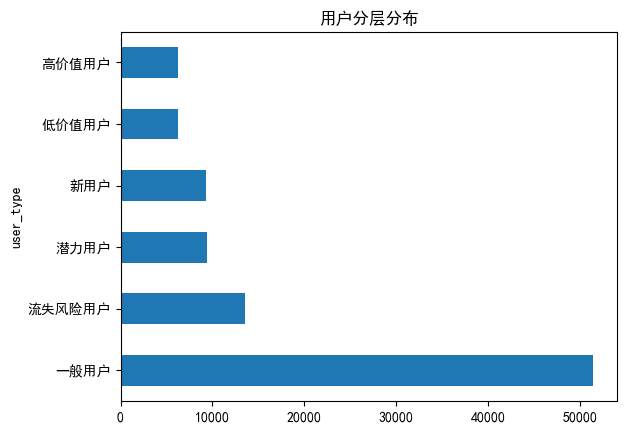

user_type
一般用户      51407
流失风险用户    13599
潜力用户       9406
新用户        9248
低价值用户      6284
高价值用户      6238
Name: count, dtype: int64


In [13]:
user_df['user_type'].value_counts().plot(kind='barh', title='用户分层分布')
plt.show()

# 打印各类用户数量
print(user_df['user_type'].value_counts())

user_df.to_csv(r"..\data\user_rfm.csv", index=False, encoding="utf-8-sig")

In [14]:
#预测高价值用户（消费金额在前20% = 高价值 = 1）
# 定义：订单数 >=2 → 复购用户 = 1
# 定义：订单数 ==1 → 非复购用户 = 0
user_df['repurchase'] = (user_df['frequency'] >= 2).astype(int)
user_df['avg_delivery_days'] = user_df['avg_delivery_days'].fillna(user_df['avg_delivery_days'].median())
user_df['avg_review_score'] = user_df['avg_review_score'].fillna(user_df['avg_review_score'].median())

monetary_threshold = user_df['monetary'].quantile(0.8)
user_df['high_value'] = np.where(
    (user_df['monetary'] >= user_df['monetary'].quantile(0.7)) | (user_df['frequency'] >= 3),
    1,
    0
)

# 查看正负样本比例
print("高价值用户分布：")
print(user_df['high_value'].value_counts(normalize=True))

高价值用户分布：
high_value
0    0.699996
1    0.300004
Name: proportion, dtype: float64


In [15]:
# 选择用于预测的特征
features = [
    'recency',        # 最近购买天数 R
    'avg_delivery_days',  # 平均物流时长
    'avg_review_score',   # 平均评分  
]

X = user_df[features]
y = user_df['high_value']

In [16]:
# 划分训练集、测试集 (7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# 训练
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# 预测
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

# 评估
print("===== 逻辑回归结果 =====")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

===== 逻辑回归结果 =====
AUC: 0.5562
              precision    recall  f1-score   support

           0       0.70      1.00      0.82     20198
           1       0.29      0.00      0.00      8657

    accuracy                           0.70     28855
   macro avg       0.50      0.50      0.41     28855
weighted avg       0.58      0.70      0.58     28855



In [18]:
# 训练
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

# 预测
y_pred_xgb = xgb.predict(X_test_scaled)
y_pred_proba_xgb = xgb.predict_proba(X_test_scaled)[:,1]

# 评估
print("\n===== XGBoost 结果 =====")
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))


===== XGBoost 结果 =====
AUC: 0.5558
              precision    recall  f1-score   support

           0       0.70      0.98      0.82     20198
           1       0.44      0.04      0.08      8657

    accuracy                           0.70     28855
   macro avg       0.57      0.51      0.45     28855
weighted avg       0.62      0.70      0.60     28855



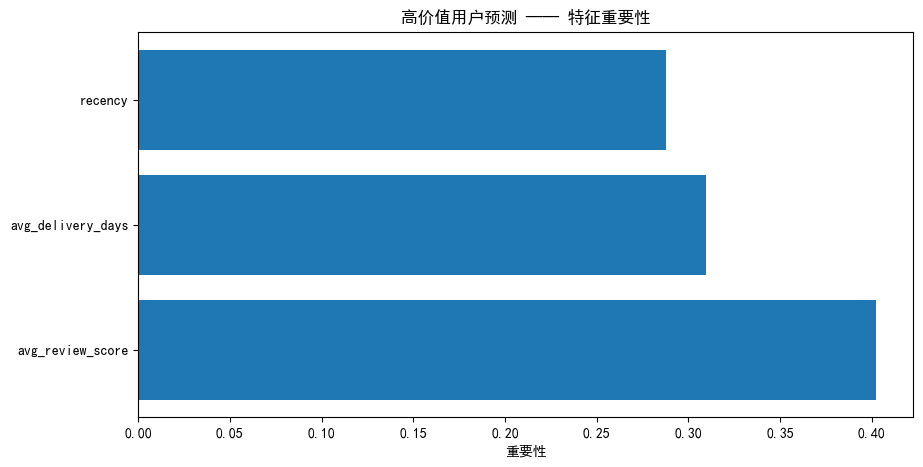

In [19]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('高价值用户预测 —— 特征重要性')
plt.xlabel('重要性')
plt.show()

user_df.to_csv(r"..\data\user_ml_result.csv", index=False, encoding="utf-8-sig")

In [20]:
# 输出结论
print("=== 业务结论 ===")
print("1. 高价值用户核心特征：高评价、物流体验好、近期活跃")
print("2. 配送时长越短，用户成为高价值用户的潜力越高")
print("3. 高评分用户对平台信任度更高，消费潜力更强")
print("4. 模型可精准识别高价值潜力用户，用于精准营销与重点运营")

=== 业务结论 ===
1. 高价值用户核心特征：高评价、物流体验好、近期活跃
2. 配送时长越短，用户成为高价值用户的潜力越高
3. 高评分用户对平台信任度更高，消费潜力更强
4. 模型可精准识别高价值潜力用户，用于精准营销与重点运营
